Quick and dirty notebook for simulation of coherent scattering data of magnetic samples in fraunhofer far-field regime

# Import

In [1]:
# Import general libraries
import sys, os
from os.path import join, split
from importlib import reload
from copy import deepcopy
from tqdm.auto import tqdm

import numpy as np

# scipy
import scipy

# plotting
import matplotlib.pyplot as plt

# Interactive plotting
import ipywidgets
%matplotlib widget
plt.rcParams["figure.constrained_layout.use"] = True

In [2]:
# Imports from our own codebase
from scattering_calculator.experimental_conditions import detector, light_beam
from scattering_calculator.sample_generator import pattern_generator, structures
from scattering_calculator.interactive.interactive_widgets import cimshow

# Experimental setup

In [3]:
# Basic parameters for the simulation
sample_shape = (2**11, 2**11)  # in pixels
real_space_pixel_size = 0.5e-9  # in m

# ===================
# X-ray Source
# ===================
x_ray_energy = 789.9  # eV
x_ray_photon_flux = 1e10  # Photons per pulse
beam_params = light_beam.beam_parameters(
    x_ray_energy, x_ray_photon_flux
)

# ==================
# Geometry
# ==================
detector_pixel_size = 10e-6  # in m
detector_pixel_shape = (2048, 2048)
detector_distance = 0.15  # in m

# Optional: Define a beamstop
beamstop_radius = 0.5e-3  # in m
beamstop_distance = 0.001  # in m
beamstop_center = np.array(detector_pixel_shape) // 2  # in px

# ==================
# Setup
# ==================

# Basic camera parameters
exp_detector = detector.detector_layout(
    pixel_size=detector_pixel_size,
    shape=detector_pixel_shape,
    distance_sample_detector=detector_distance,
)

# Add beamstop to detector layout
beamstop = detector.beamstop(exp_detector, beamstop_distance)
beamstop.create_circle_beamstop(beamstop_center, beamstop_radius,use_real_space_coordinates=True)
bs_mask = beamstop.return_beamstop()
exp_detector.assign_beamstop(bs_mask)

Text(0, 0.5, 'y in mm')

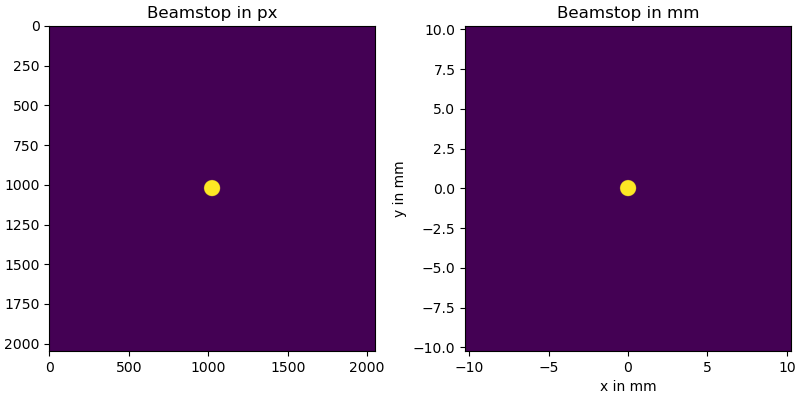

In [4]:
# Plot beamstop
extent_det_real = exp_detector.get_detector_extent_real_space()

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(exp_detector.beamstop_mask)
ax[0].set_title("Beamstop in px")
ax[1].imshow(exp_detector.beamstop_mask, extent=1e3*extent_det_real)
ax[1].set_title("Beamstop in mm")
ax[1].set_xlabel("x in mm")
ax[1].set_ylabel("y in mm")

# Illumination function

In [5]:
reload(light_beam)

<module 'scattering_calculator.experimental_conditions.light_beam' from '/Users/riccardo/fomocid/src/scattering_calculator/experimental_conditions/light_beam.py'>

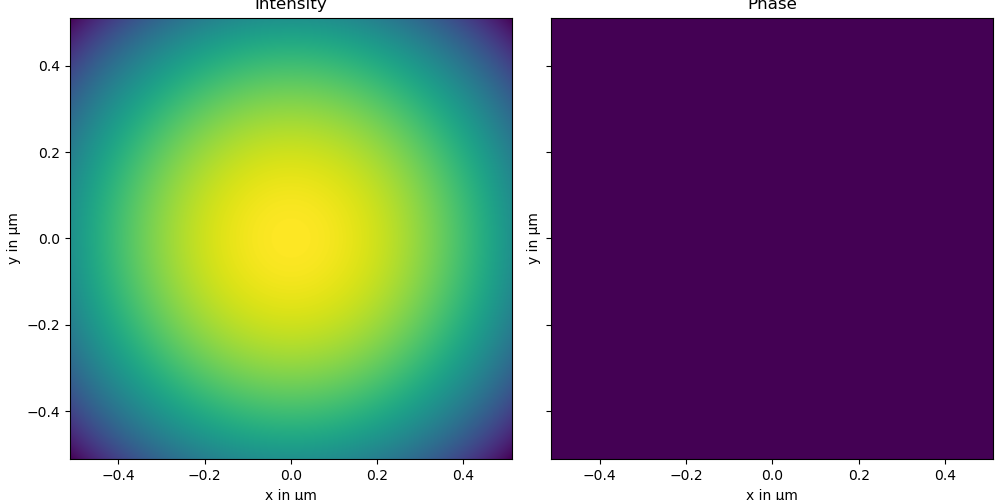

In [6]:
# Params for gaussian beam
illumination_function = "gaussian"
illumination_center = np.array(sample_shape) // 2  # in px
illumination_focus_distance = 0#in m
illumination_fwhm = 30e-6  # in m

illumination = light_beam.illumination(beam_params, sample_shape, real_space_pixel_size)

# Comment: Check gauss_beam function for different focus distances
illumination.gauss_beam(
    illumination_center,
    illumination_focus_distance,
    illumination_fwhm,
)
illumination_wavefield = illumination.return_illumination()
extent_illumination_real = illumination.get_illumination_extent_real_space()
illumination.visualize_illumination()

# Sample

In [7]:
reload(structures)

<module 'scattering_calculator.sample_generator.structures' from '/Users/riccardo/fomocid/src/scattering_calculator/sample_generator/structures.py'>

## Front Aperture

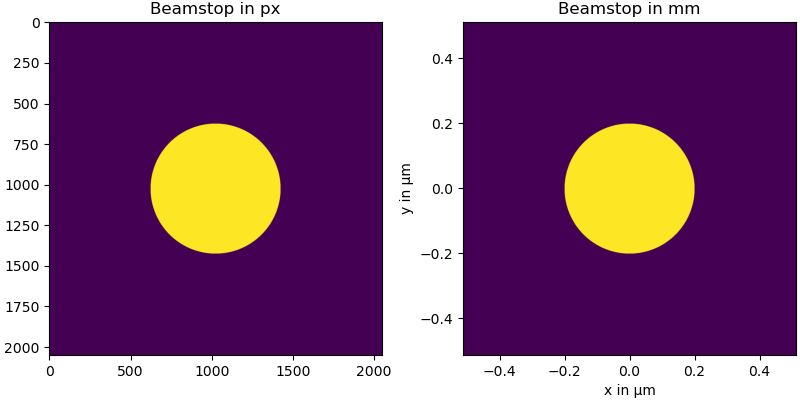

In [8]:
front_aperture_radius = 0.2e-6  # in m
front_aperture = structures.Apertures(sample_shape, real_space_pixel_size)
front_aperture.create_circle_aperture(
    center=(sample_shape[0] // 2, sample_shape[1] // 2),
    radius=front_aperture_radius,
    use_real_space_coordinates=True
)
front_aperture.visualize_aperture()

## Layer structure

In [9]:
reload(structures)

<module 'scattering_calculator.sample_generator.structures' from '/Users/riccardo/fomocid/src/scattering_calculator/sample_generator/structures.py'>

In [ ]:
reload(structures)

recipe = "[Au(3)/Cr(3)]x100/SiN(200)/Ta(5)/[Pt(1)/Co(1)]x15/Pt(3)"

# define stack
stack = structures.parse_recipe(
    recipe,
    sample_name="sample_A",
    comments=["test multilayer"],
)

#pulls material refractive indexes
material_params = structures.material_params(materials=set([element.material for element in stack.layers]), 
                             x_ray_energy=x_ray_energy)

print(stack.summary())




Sample: sample_A
Recipe: [Au(3)/Cr(3)]x100/SiN(200)/Ta(5)/[Pt(1)/Co(1)]x15/Pt(3)
Number of layers: 233
Total thickness: 8.38e-07 m
Comments:
  - test multilayer


Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
Au
Cr
SiN
Ta
Pt
Co
Pt
Co
Pt
Co
Pt
Co
Pt
Co
Pt
Co
Pt
Co
Pt
Co
Pt
Co
Pt
Co
Pt
Co
Pt
Co
Pt
Co
Pt
Co
Pt
Co
Pt


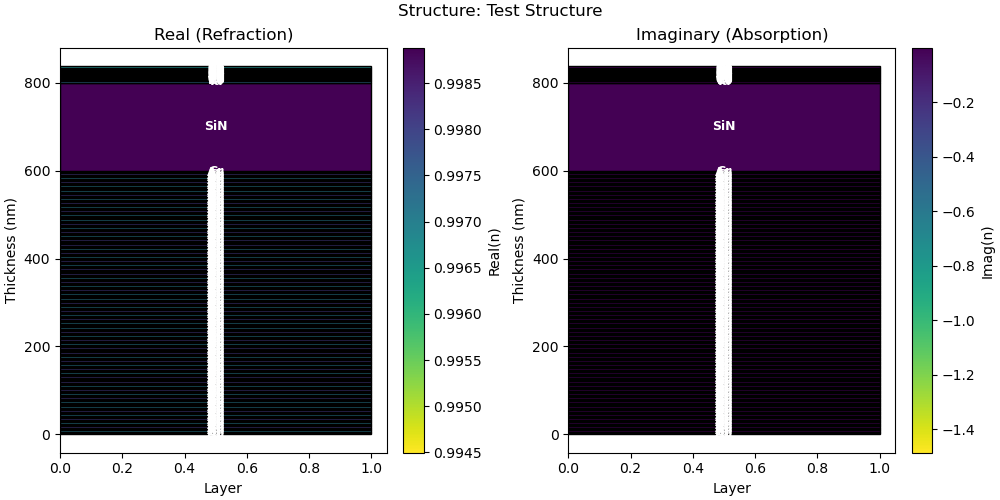

(8.362040292986446e-07-2.326528865742945e-08j)

In [11]:
non_magnetic_structure = structures.Structure(
    name="Test Structure",
    material_params=material_params
)

for layer in stack.layers:
    non_magnetic_structure.add_layer(layer.material, thickness=layer.thickness)


non_magnetic_structure.visualize_structure()
non_magnetic_structure.return_total_effective_refractive_index()



In [ ]:
non_magnetic_structure = structures.Structure(
    name="Test Structure",
    material_params=material_params
)

for layer in stack.layers:
    non_magnetic_structure.add_layer(layer.material, thickness=layer.thickness)


non_magnetic_structure.visualize_structure()
non_magnetic_structure.return_total_effective_refractive_index()



In [ ]:
non_magnetic_structure = structures.Structure(
    name="Test Structure",
    material_params=material_params
)
non_magnetic_structure.add_layer("SiN", thickness=100e-9)
non_magnetic_structure.add_layer("Ta", thickness=3e-9)
for i in range(15):
    non_magnetic_structure.add_layer("Co", thickness=1e-9)
    non_magnetic_structure.add_layer("Pt", thickness=3e-9)                                                      
non_magnetic_structure.add_layer("Co", thickness=1e-9)

non_magnetic_structure.visualize_structure()
non_magnetic_structure.return_total_effective_refractive_index()

(0.994497977970506-1.4850530275072418j)
(0.994497977970506-1.4850530275072418j)
(0.994497977970506-1.4850530275072418j)
(0.994497977970506-1.4850530275072418j)
(0.994497977970506-1.4850530275072418j)
(0.994497977970506-1.4850530275072418j)
(0.994497977970506-1.4850530275072418j)
(0.994497977970506-1.4850530275072418j)
(0.994497977970506-1.4850530275072418j)
(0.994497977970506-1.4850530275072418j)
(0.994497977970506-1.4850530275072418j)
(0.994497977970506-1.4850530275072418j)
(0.994497977970506-1.4850530275072418j)
(0.994497977970506-1.4850530275072418j)
(0.994497977970506-1.4850530275072418j)
(0.994497977970506-1.4850530275072418j)


/Users/riccardo/fomocid/src/scattering_calculator/sample_generator/structures.py:429: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, 2, figsize=(10, 5))


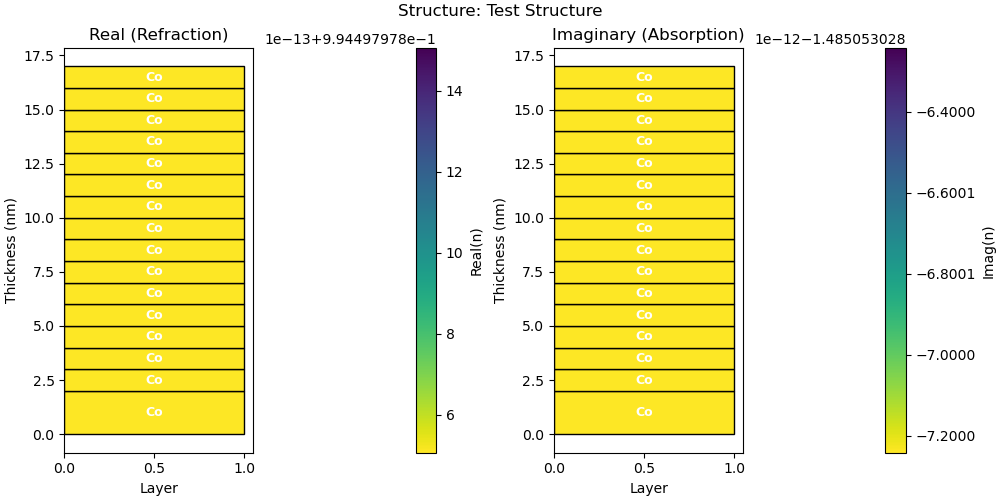

(1.6906465625498606e-08-2.5245901467623115e-08j)

In [118]:
magnetic_structure = structures.Structure(
    name="Test Structure", material_params=material_params
)
magnetic_structure.add_layer("Co", thickness=2e-9)
for i in range(15):
    magnetic_structure.add_layer("Co", thickness=1e-9)

magnetic_structure.visualize_structure()
magnetic_structure.return_total_effective_refractive_index()

## Magnetic pattern